# 01 · Comparación de Modelos — OLS vs. LASSO
## Tópicos de Estadística Avanzada · UNS

**Prerrequisito:** `datos_crudos.csv` en el directorio de trabajo.  
El notebook es genérico: adaptá `TARGET` y `ROCK_TYPE` a tu dataset.

**Estructura:**
1. Librerías y configuración
2. Carga de datos crudos
3. Limpieza y transformación  
   - Paso 1: eliminar filas sin respuesta  
   - Paso 2: selección por cobertura ≥ 50%  
   - Paso 2b: tratamiento de valores de censura (negativos → LOD/2)  
   - Paso 3: imputación por mediana  
   - Paso 4: winsorización 1%–99%  
   - Paso 5: transformación log(1+x)  
   - Paso 6: one-hot encoding  
   - Paso 7: eliminar varianza cero / colinealidad perfecta  
4. Renombrado genérico X1..Xp + split train/test + estandarización
5. Exploración: correlaciones y VIF
6. Ajuste OLS
7. Ajuste LASSO + path de coeficientes
8. Comparación por AIC y BIC *(Sección 4.1 del teórico)*
9. Validación cruzada K-fold *(Sección 4.2)*
10. Test de Diebold-Mariano *(Sección 4.2.4)*
11. Bootstrap paramétrico *(Sección 4.3)*
12. Síntesis *(Sección 5)*

Las columnas de predictores se renombran a **X1, X2, ..., Xp** para que
el notebook sea reutilizable con cualquier dataset.

## 1. Librerías y configuración

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import mstats, stats
from scipy.stats import t as t_dist
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from numpy.linalg import matrix_rank

# ── Parámetros globales ───────────────────────────────────────────────────────
SEED   = 42
K_FOLD = 10
B_BOOT = 500    # reducir a 200 si el dataset es muy grande
np.random.seed(SEED)

# ── Estilo ────────────────────────────────────────────────────────────────────
UNS_BLUE   = "#1E3C78"
UNS_ORANGE = "#B43C14"
plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

print(f"Configuración lista.  K_FOLD={K_FOLD}  B_BOOT={B_BOOT}  SEED={SEED}")


Configuración lista.  K_FOLD=10  B_BOOT=500  SEED=42


## 2. Carga de datos crudos

Cargamos el CSV generado por `00_ETL.ipynb`.
Los datos tienen valores faltantes reales que trataremos en la sección siguiente.


In [2]:
df = pd.read_csv("datos_crudos.csv")

# TARGET y FEATURES se definen aquí — adaptá si tu dataset usa otro nombre
TARGET   = "Cu"
FEATURES = [c for c in df.columns if c != TARGET]

print(f"Shape cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Target  : {TARGET}")
print(f"Features: {FEATURES}")
print(f"\nCobertura (% no nulo):")
print((df[FEATURES + [TARGET]].notna().mean() * 100).round(1).sort_values().to_string())

Shape cargado: 4,776 filas × 19 columnas
Target  : Cu
Features: ['SiO2', 'Al2O3', 'Fe2O3', 'MgO', 'CaO', 'Na2O', 'K2O', 'TiO2', 'MnO', 'P2O5', 'Mo', 'Pb', 'Zn', 'As', 'Sb', 'Bi', 'Ag', 'ROCK_TYPE']

Cobertura (% no nulo):
SiO2           0.0
Al2O3          0.0
Fe2O3          0.0
MgO            0.0
CaO            0.0
Na2O           0.0
K2O            0.0
TiO2           0.0
MnO            0.0
P2O5           0.0
Sb             4.0
Mo           100.0
Pb           100.0
Zn           100.0
As           100.0
Bi           100.0
Ag           100.0
ROCK_TYPE    100.0
Cu           100.0


## 3. Limpieza y transformación

Pipeline completo de limpieza sobre los datos crudos.

**Pasos:**
1. Eliminar filas sin Cu (variable respuesta).
2. Seleccionar variables con cobertura ≥ 50%.
3. Imputar faltantes por mediana dentro de tipo de roca, luego mediana global.
4. Winsorizar al 1%–99% para reducir el efecto de outliers extremos.
5. Transformación log(1+x) en variables con distribución sesgada.
6. One-hot encoding de la variable categórica `ROCK_TYPE`.
7. Eliminar columnas con varianza cero o colinealidad perfecta.

> 📖 Ver Anexo A del material teórico.


In [4]:
# ── Paso 1: Eliminar filas sin Cu ────────────────────────────────────────────
antes = len(df)
df = df.dropna(subset=[TARGET])
df = df[df[TARGET] > 0].copy()
print(f"Paso 1 — Eliminadas {antes - len(df):,} filas sin Cu. Restantes: {len(df):,}")


Paso 1 — Eliminadas 0 filas sin Cu. Restantes: 4,776


In [5]:
# ── Paso 2: Selección por cobertura ──────────────────────────────────────────
UMBRAL = 0.50
features_num = [f for f in FEATURES if f != "ROCK_TYPE" and f in df.columns]

cobertura = df[features_num].notna().mean()
FEATURES_NUM_OK = cobertura[cobertura >= UMBRAL].index.tolist()

# ROCK_TYPE la manejamos aparte (one-hot en Paso 6)
tiene_rock_type = "ROCK_TYPE" in df.columns and df["ROCK_TYPE"].notna().mean() >= UMBRAL

print(f"Variables numéricas con cobertura >= {UMBRAL:.0%}: {len(FEATURES_NUM_OK)}")
for f in FEATURES_NUM_OK:
    print(f"  {f:<14}  {cobertura[f]:.1%}")
print(f"\nROCK_TYPE disponible: {tiene_rock_type}")

Variables numéricas con cobertura >= 50%: 6
  Mo              100.0%
  Pb              100.0%
  Zn              100.0%
  As              100.0%
  Bi              100.0%
  Ag              100.0%

ROCK_TYPE disponible: True


In [6]:
# Cobertura completa de features seleccionados
if len(FEATURES_NUM_OK) > 0:
    print(cobertura[FEATURES_NUM_OK].sort_values().to_string())
else:
    print("⚠ Ninguna variable numérica supera el umbral de cobertura.")

# ── Paso 2b: Tratamiento de valores de censura ───────────────────────────────
# Valores negativos son códigos analíticos (e.g. -50 = "< límite de detección")
# Estrategia: reemplazar por LOD/2 = min_positivo / 2
print("\nTratamiento de censura (valores < 0):")
for col in FEATURES_NUM_OK:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        min_pos = df[col][df[col] > 0].min()
        lod2 = min_pos / 2
        df[col] = df[col].clip(lower=lod2)
        print(f"  {col}: {n_neg:,} valores negativos → reemplazados por LOD/2 = {lod2:.3f}")
    else:
        print(f"  {col}: sin valores de censura")
print("\n✓ Censura tratada.")

Mo    1.0
Pb    1.0
Zn    1.0
As    1.0
Bi    1.0
Ag    1.0

Tratamiento de censura (valores < 0):
  Mo: 2,471 valores negativos → reemplazados por LOD/2 = 1.000
  Pb: 12 valores negativos → reemplazados por LOD/2 = 2.000
  Zn: sin valores de censura
  As: 3,350 valores negativos → reemplazados por LOD/2 = 2.500
  Bi: 4,769 valores negativos → reemplazados por LOD/2 = 5.000
  Ag: 4,737 valores negativos → reemplazados por LOD/2 = 0.250

✓ Censura tratada.


In [7]:
# ── Paso 3: Imputación por mediana ───────────────────────────────────────────
if tiene_rock_type:
    for col in FEATURES_NUM_OK:
        df[col] = df.groupby("ROCK_TYPE")[col].transform(
            lambda x: x.fillna(x.median())
        )

# Mediana global para los NaN restantes
for col in FEATURES_NUM_OK:
    n_nan = df[col].isna().sum()
    if n_nan > 0:
        df[col] = df[col].fillna(df[col].median())

print(f"NaN restantes en features numéricos: {df[FEATURES_NUM_OK].isna().sum().sum()}")


NaN restantes en features numéricos: 0


In [8]:
# ── Paso 4: Winsorización 1%–99% ─────────────────────────────────────────────
for col in FEATURES_NUM_OK + [TARGET]:
    df[col] = mstats.winsorize(df[col].values, limits=[0.01, 0.01])

print("Winsorización aplicada.")


Winsorización aplicada.


log(1+x) aplicado a: ['Bi', 'Mo', 'Pb', 'Zn', 'Ag', 'Cu', 'As']


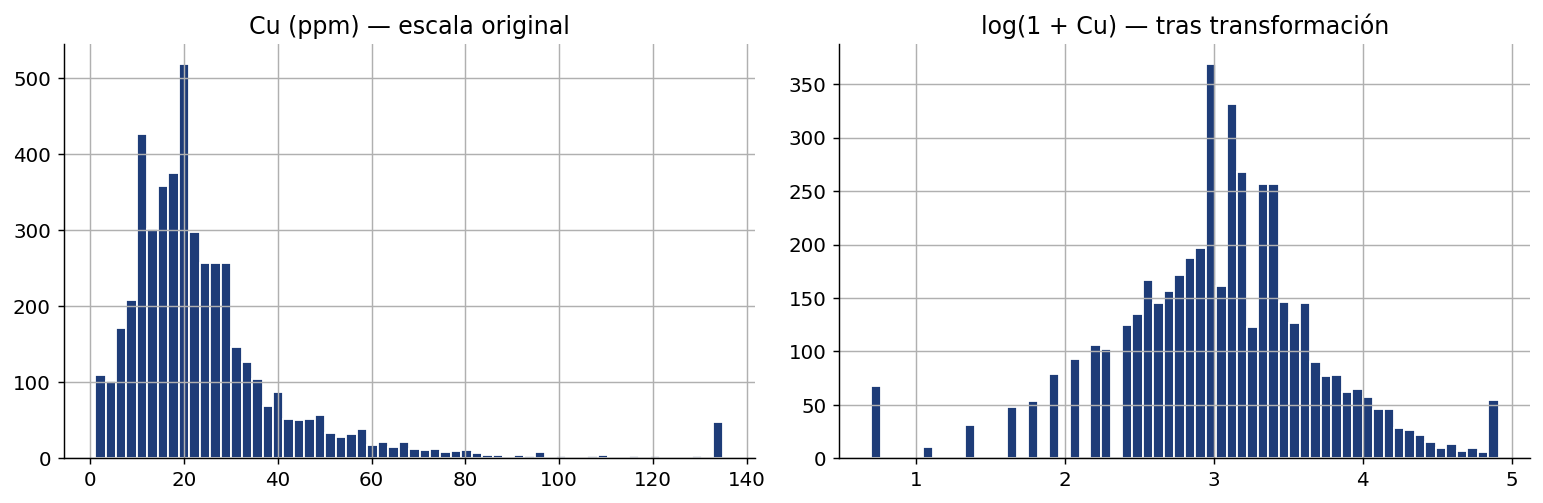

In [9]:
# ── Paso 5: Transformación logarítmica ───────────────────────────────────────
# Variables traza y Cu tienen distribuciones fuertemente asimétricas (log-normales)
VARS_LOG = [v for v in ["Cu", "Mo", "Pb", "Zn", "As", "Bi", "Ag", TARGET]
            if v in df.columns]
VARS_LOG = list(set(VARS_LOG))   # evitar duplicados si TARGET == "Cu"

for col in VARS_LOG:
    df[col] = np.log1p(df[col])

print(f"log(1+x) aplicado a: {VARS_LOG}")

# Visualizar resultado sobre Cu
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
np.expm1(df[TARGET]).hist(bins=60, ax=axes[0], color=UNS_BLUE, edgecolor="white")
axes[0].set_title("Cu (ppm) — escala original")
df[TARGET].hist(bins=60, ax=axes[1], color=UNS_BLUE, edgecolor="white")
axes[1].set_title("log(1 + Cu) — tras transformación")
plt.tight_layout()
plt.savefig("dist_Cu_transformada.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# ── Paso 6: One-hot encoding de ROCK_TYPE ────────────────────────────────────
if tiene_rock_type:
    print(f"Categorías de ROCK_TYPE:")
    print(df["ROCK_TYPE"].value_counts().to_string())
    df = pd.get_dummies(df, columns=["ROCK_TYPE"], drop_first=True, dtype=float)
    print(f"\nColumnas tras one-hot: {df.shape[1]}")

# FEATURES_MODELO = solo los que pasaron cobertura + dummies de ROCK_TYPE
# (NO incluir columnas con 0% de cobertura que puedan existir en el CSV)
ROCK_DUMMIES    = [c for c in df.columns if c.startswith("ROCK_TYPE_")]
FEATURES_MODELO = FEATURES_NUM_OK + ROCK_DUMMIES
print(f"\nTotal features para modelado: {len(FEATURES_MODELO)}")
print(FEATURES_MODELO)

Categorías de ROCK_TYPE:
ROCK_TYPE
metamorphic        2448
igneous            1809
carbonate           324
shale               142
coarse clastics      53

Columnas tras one-hot: 22

Total features para modelado: 10
['Mo', 'Pb', 'Zn', 'As', 'Bi', 'Ag', 'ROCK_TYPE_coarse clastics', 'ROCK_TYPE_igneous', 'ROCK_TYPE_metamorphic', 'ROCK_TYPE_shale']


In [11]:
# Paso 7 a continuación: eliminar features con varianza ~0 o colinealidad perfecta

In [12]:
# ── Paso 7: Eliminar columnas con varianza cero o colinealidad perfecta ───────

# Seleccionar solo columnas numéricas (defensa contra datasets con cols string)
X_all = df[FEATURES_MODELO].select_dtypes(include='number')
FEATURES_MODELO = X_all.columns.tolist()

# Varianza cero (ocurre cuando todos los valores quedan igual tras censura/winsorización)
var_cero = X_all.var()[X_all.var() < 1e-10].index.tolist()
if var_cero:
    print(f"Eliminadas por varianza ~0: {var_cero}")
    FEATURES_MODELO = [f for f in FEATURES_MODELO if f not in var_cero]
else:
    print("Sin variables de varianza cero.")

# Colinealidad perfecta (|correlación| > 0.9999)
# Nota: .where() introduce NaN en la triangular inferior;
# usar .dropna().any() en lugar de any() built-in para evitar
# el error "ufunc 'greater' ... StrDType" en pandas 3 + numpy 2
X_check  = df[FEATURES_MODELO].select_dtypes(include='number')
corr_abs = X_check.corr().abs()
upper    = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
col_perf = [c for c in upper.columns if (upper[c].dropna() > 0.9999).any()]
if col_perf:
    print(f"Eliminadas por colinealidad perfecta: {col_perf}")
    FEATURES_MODELO = [f for f in FEATURES_MODELO if f not in col_perf]
else:
    print("Sin colinealidad perfecta detectada.")

# Verificación de rango (defensivo)
n_check = min(6, len(FEATURES_MODELO))
if n_check >= 2:
    rango = matrix_rank(df[FEATURES_MODELO[:n_check]].values)
    print(f"\nRango de subconjunto ({n_check} cols): {rango}")

print(f"\nFeatures finales para modelado: {len(FEATURES_MODELO)}")
print(FEATURES_MODELO)

Eliminadas por varianza ~0: ['Bi', 'Ag']
Sin colinealidad perfecta detectada.

Rango de subconjunto (6 cols): 6

Features finales para modelado: 8
['Mo', 'Pb', 'Zn', 'As', 'ROCK_TYPE_coarse clastics', 'ROCK_TYPE_igneous', 'ROCK_TYPE_metamorphic', 'ROCK_TYPE_shale']


In [13]:
# Mapeo genérico X1..Xp → nombre original (referencia rápida)
for i, f in enumerate(FEATURES_MODELO):
    print(f"  X{i+1:<3} ← {f}")

  X1   ← Mo
  X2   ← Pb
  X3   ← Zn
  X4   ← As
  X5   ← ROCK_TYPE_coarse clastics
  X6   ← ROCK_TYPE_igneous
  X7   ← ROCK_TYPE_metamorphic
  X8   ← ROCK_TYPE_shale


## 4. Renombrado genérico y split train/test

Renombramos los predictores a **X1, X2, ..., Xp** para que el análisis
sea independiente del dominio. El mapeo queda guardado en `mapeo_vars`.

El split es estratificado por quintiles de `y` para garantizar distribución
similar de valores altos y bajos de Cu en ambos conjuntos.

> 📖 Ver Sección 1.4 del material teórico — formulación OLS y LASSO.


In [14]:
# Renombrado genérico
mapeo_orig_a_gen = {feat: f"X{i+1}" for i, feat in enumerate(FEATURES_MODELO)}
mapeo_gen_a_orig = {v: k for k, v in mapeo_orig_a_gen.items()}

X_gen = df[FEATURES_MODELO].rename(columns=mapeo_orig_a_gen)
y_ser = df[TARGET]
GEN_COLS = X_gen.columns.tolist()

print("Mapeo (primeros 15):")
for orig, gen in list(mapeo_orig_a_gen.items())[:15]:
    print(f"  {gen:<6} ← {orig}")
if len(mapeo_orig_a_gen) > 15:
    print(f"  ...  ({len(GEN_COLS)} variables en total)")


Mapeo (primeros 15):
  X1     ← Mo
  X2     ← Pb
  X3     ← Zn
  X4     ← As
  X5     ← ROCK_TYPE_coarse clastics
  X6     ← ROCK_TYPE_igneous
  X7     ← ROCK_TYPE_metamorphic
  X8     ← ROCK_TYPE_shale


In [15]:
# Split estratificado 80/20
y_bin = pd.qcut(y_ser, q=5, labels=False, duplicates="drop")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_gen, y_ser,
    test_size=0.2, random_state=SEED, stratify=y_bin
)

print(f"Train: {X_train_raw.shape[0]:,} × {X_train_raw.shape[1]}")
print(f"Test : {X_test_raw.shape[0]:,} × {X_test_raw.shape[1]}")


Train: 3,820 × 8
Test : 956 × 8


In [16]:
# Estandarización — fit SOLO sobre train
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=GEN_COLS, index=X_train_raw.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=GEN_COLS, index=X_test_raw.index
)

print("Media en train (debe ser ~0):")
print(X_train.mean().describe())
print("\nDesvío en train (debe ser ~1):")
print(X_train.std().describe())


Media en train (debe ser ~0):
count    8.000000e+00
mean     2.641866e-16
std      5.888364e-16
min     -2.752888e-16
25%     -6.242825e-17
50%      2.325074e-18
75%      3.878224e-16
max      1.478747e-15
dtype: float64

Desvío en train (debe ser ~1):
count    8.000000e+00
mean     1.000131e+00
std      1.186878e-16
min      1.000131e+00
25%      1.000131e+00
50%      1.000131e+00
75%      1.000131e+00
max      1.000131e+00
dtype: float64


## 5. Exploración del espacio de predictores

Visualizamos la estructura de correlación entre predictores.
Alta correlación indica multicolinealidad, el problema central que motiva LASSO.

> 📖 Ver Sección 2.1 del material teórico — Supuesto S4.


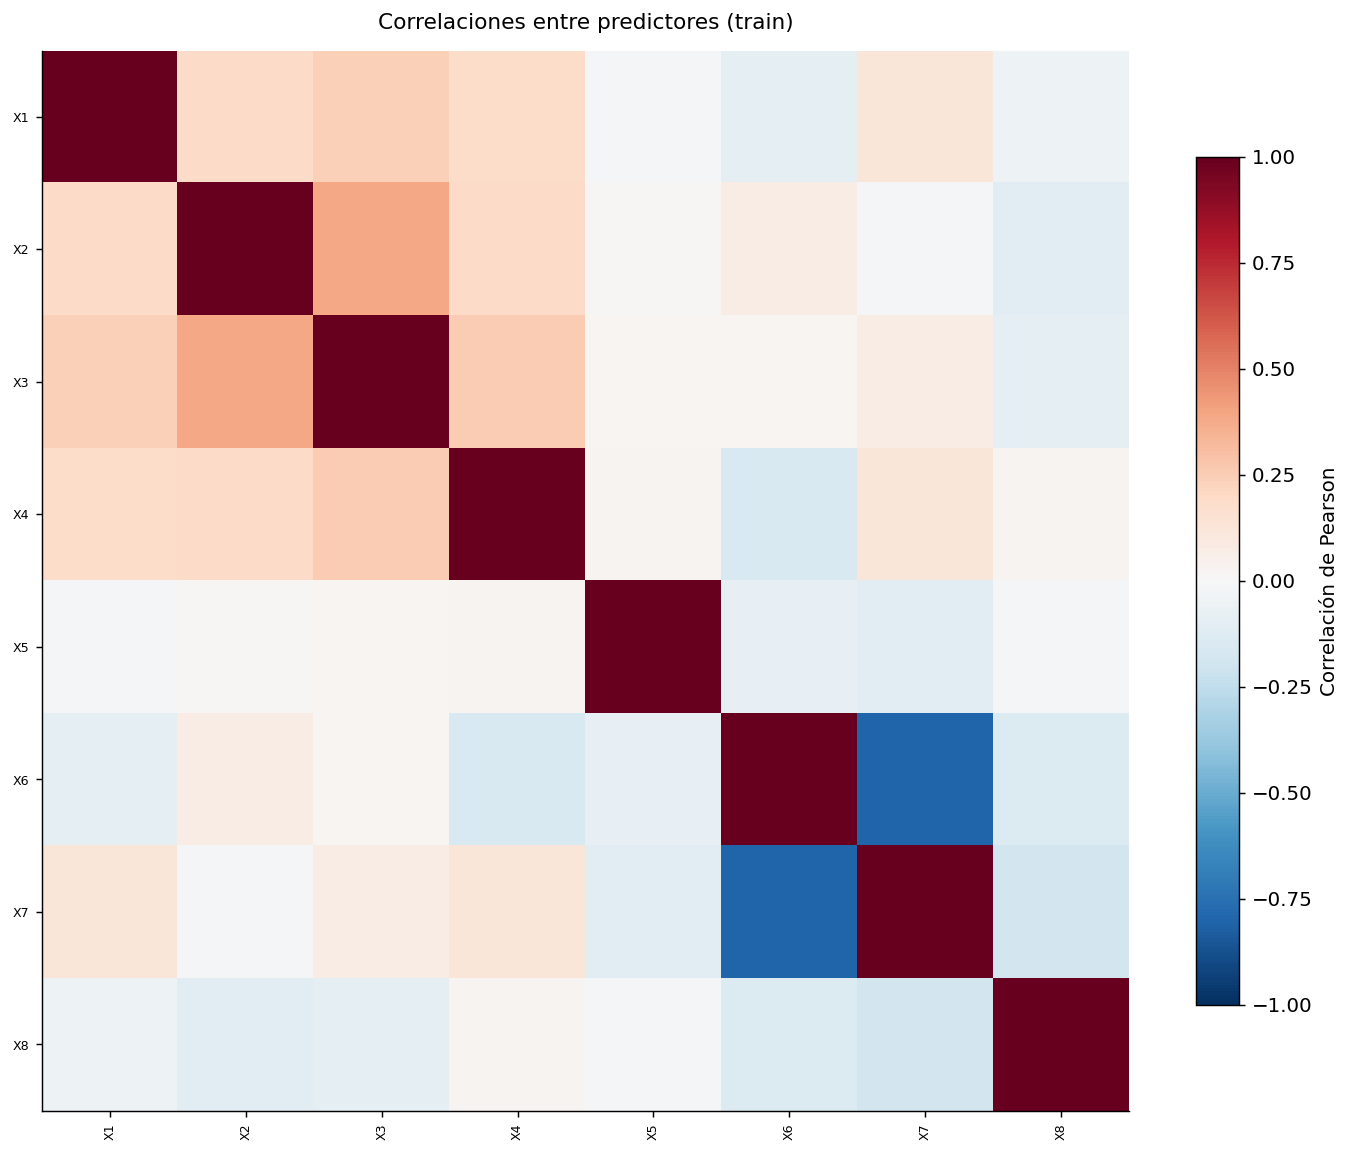

In [17]:
# Matriz de correlaciones
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8, label="Correlación de Pearson")
n = len(GEN_COLS)
ax.set_xticks(range(n)); ax.set_xticklabels(GEN_COLS, rotation=90, fontsize=7)
ax.set_yticks(range(n)); ax.set_yticklabels(GEN_COLS, fontsize=7)
ax.set_title("Correlaciones entre predictores (train)", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# VIF — Factor de Inflación de Varianza
# VIF_j = 1 / (1 - R²_j)  donde R²_j = R² de X_j regresionado sobre las demás
from numpy.linalg import lstsq

def calcular_vif(X_df):
    Xv = X_df.values
    vifs = {}
    for j, col in enumerate(X_df.columns):
        y_j = Xv[:, j]
        X_j = np.delete(Xv, j, axis=1)
        Xa  = np.c_[np.ones(len(y_j)), X_j]
        coef, *_ = lstsq(Xa, y_j, rcond=None)
        y_hat = Xa @ coef
        ss_res = np.sum((y_j - y_hat) ** 2)
        ss_tot = np.sum((y_j - y_j.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vifs[col] = round(1 / (1 - r2), 2) if r2 < 1 else np.inf
    return pd.Series(vifs).sort_values(ascending=False)

vif = calcular_vif(X_train)
print("VIF por predictor (top 20):")
print(vif.head(20).to_string())
print(f"\nVariables con VIF > 10: {(vif > 10).sum()} de {len(vif)}")
print("→ Alta multicolinealidad justifica el uso de LASSO sobre OLS.")

VIF por predictor (top 20):
X7    4.20
X6    4.16
X8    1.41
X3    1.28
X2    1.22
X5    1.15
X4    1.13
X1    1.10

Variables con VIF > 10: 0 de 8
→ Alta multicolinealidad justifica el uso de LASSO sobre OLS.


In [19]:
X_train

,X1,X2,X3,X4,X5,X6,X7,X8
3269,-0.870226,-0.685639,-0.837383,-0.612147,-0.102869,1.282743,-1.023844,-0.178535
4234,-0.870226,-0.685639,0.251562,-0.612147,-0.102869,-0.779579,0.976711,-0.178535
4507,-0.870226,-0.685639,0.045724,-0.612147,-0.102869,1.282743,-1.023844,-0.178535
1708,1.295985,-0.205227,0.201871,-0.612147,-0.102869,-0.779579,0.976711,-0.178535
1564,1.295985,0.519172,0.125175,1.144862,-0.102869,1.282743,-1.023844,-0.178535
...,...,...,...,...,...,...,...,...
951,0.714175,-0.685639,-1.966900,-0.612147,-0.102869,-0.779579,0.976711,-0.178535
3173,-0.870226,0.999584,0.462308,-0.612147,-0.102869,1.282743,-1.023844,-0.178535
2716,-0.870226,-0.432061,0.151037,1.232304,-0.102869,1.282743,-1.023844,-0.178535
3991,-0.870226,1.232560,0.906023,0.839210,-0.102869,-0.779579,0.976711,-0.178535


## 6. OLS — punto de referencia

Ajustamos OLS usando todos los predictores disponibles.
Si hay multicolinealidad severa residual, usamos Ridge con α muy pequeño
como aproximación numérica estable de OLS.

> 📖 Ver Sección 2 del material teórico.


In [20]:
try:
    ols = LinearRegression()
    ols.fit(X_train, y_train)
    OLS_LABEL = "OLS"
    print("✓ OLS ajustado correctamente.")
except np.linalg.LinAlgError:
    print("⚠ OLS falló (SVD no convergió). Multicolinealidad severa.")
    print("  Usando Ridge(α=1e-8) como OLS regularizado.")
    ols = Ridge(alpha=1e-8)
    ols.fit(X_train, y_train)
    OLS_LABEL = "Ridge(α≈0)"

y_pred_ols_train = ols.predict(X_train)
y_pred_ols_test  = ols.predict(X_test)

mse_ols_train = mean_squared_error(y_train, y_pred_ols_train)
mse_ols_test  = mean_squared_error(y_test,  y_pred_ols_test)
r2_ols_train  = r2_score(y_train, y_pred_ols_train)
r2_ols_test   = r2_score(y_test,  y_pred_ols_test)

print(f"\n{OLS_LABEL} — Resultados")
print(f"{'─'*35}")
print(f"  Predictores   : {X_train.shape[1]}")
print(f"  MSE  train    : {mse_ols_train:.4f}")
print(f"  MSE  test     : {mse_ols_test:.4f}")
print(f"  R²   train    : {r2_ols_train:.4f}")
print(f"  R²   test     : {r2_ols_test:.4f}")


✓ OLS ajustado correctamente.

OLS — Resultados
───────────────────────────────────
  Predictores   : 8
  MSE  train    : 0.3425
  MSE  test     : 0.3720
  R²   train    : 0.2517
  R²   test     : 0.2515


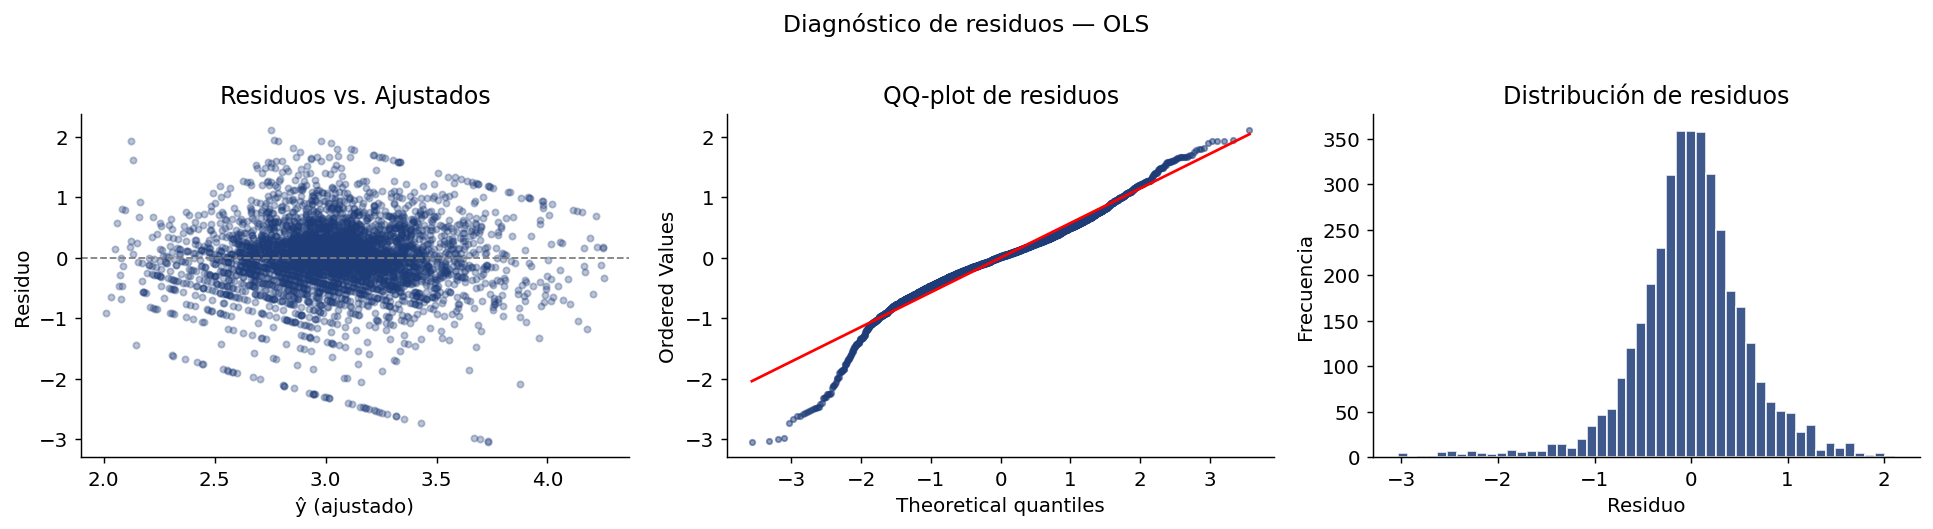

In [22]:
from scipy.stats import probplot

# Diagnóstico de residuos OLS
residuos_ols = y_train.values - y_pred_ols_train

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_ols_train, residuos_ols, alpha=0.3, s=12, color=UNS_BLUE)
axes[0].axhline(0, color="gray", lw=1, ls="--")
axes[0].set_xlabel("ŷ (ajustado)")
axes[0].set_ylabel("Residuo")
axes[0].set_title("Residuos vs. Ajustados")

probplot(residuos_ols, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot de residuos")
axes[1].get_lines()[0].set(color=UNS_BLUE, markersize=3, alpha=0.5)

axes[2].hist(residuos_ols, bins=50, color=UNS_BLUE, edgecolor="white", alpha=0.85)
axes[2].set_xlabel("Residuo")
axes[2].set_ylabel("Frecuencia")
axes[2].set_title("Distribución de residuos")

plt.suptitle(f"Diagnóstico de residuos — {OLS_LABEL}", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("diagnostico_ols.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. LASSO — selección de λ por CV interno

Ajustamos LASSO con `LassoCV`. El CV interno elige λ óptimo.

> ⚠️ Este CV **no** es el mismo que el CV de comparación de la Sección 8.
> Aquí calibramos λ; allá comparamos modelos.
>
> 📖 Ver Sección 3 del material teórico.


In [23]:
kf_interno = KFold(n_splits=5, shuffle=True, random_state=SEED)

lasso_cv = LassoCV(cv=kf_interno, max_iter=20_000, n_alphas=100, random_state=SEED)
lasso_cv.fit(X_train, y_train)

lambda_opt  = lasso_cv.alpha_
coef_lasso  = lasso_cv.coef_
df_lasso    = int((coef_lasso != 0).sum())   # grados de libertad efectivos

y_pred_lasso_train = lasso_cv.predict(X_train)
y_pred_lasso_test  = lasso_cv.predict(X_test)

mse_lasso_train = mean_squared_error(y_train, y_pred_lasso_train)
mse_lasso_test  = mean_squared_error(y_test,  y_pred_lasso_test)
r2_lasso_train  = r2_score(y_train, y_pred_lasso_train)
r2_lasso_test   = r2_score(y_test,  y_pred_lasso_test)

print(f"LASSO — Resultados")
print(f"{'─'*40}")
print(f"  λ óptimo (CV interno) : {lambda_opt:.6f}")
print(f"  df(λ) = coef no nulos : {df_lasso} de {len(coef_lasso)}")
print(f"  MSE  train            : {mse_lasso_train:.4f}")
print(f"  MSE  test             : {mse_lasso_test:.4f}")
print(f"  R²   train            : {r2_lasso_train:.4f}")
print(f"  R²   test             : {r2_lasso_test:.4f}")

print(f"\nVariables seleccionadas por LASSO:")
for xi, ci in zip(GEN_COLS, coef_lasso):
    if ci != 0:
        orig = mapeo_gen_a_orig.get(xi, xi)
        print(f"  {xi} ({orig:<14}): {ci:+.4f}")


LASSO — Resultados
────────────────────────────────────────
  λ óptimo (CV interno) : 0.000308
  df(λ) = coef no nulos : 8 de 8
  MSE  train            : 0.3425
  MSE  test             : 0.3720
  R²   train            : 0.2517
  R²   test             : 0.2515

Variables seleccionadas por LASSO:
  X1 (Mo            ): -0.0852
  X2 (Pb            ): -0.0260
  X3 (Zn            ): +0.3091
  X4 (As            ): +0.1231
  X5 (ROCK_TYPE_coarse clastics): +0.0109
  X6 (ROCK_TYPE_igneous): -0.0296
  X7 (ROCK_TYPE_metamorphic): -0.0186
  X8 (ROCK_TYPE_shale): +0.0105


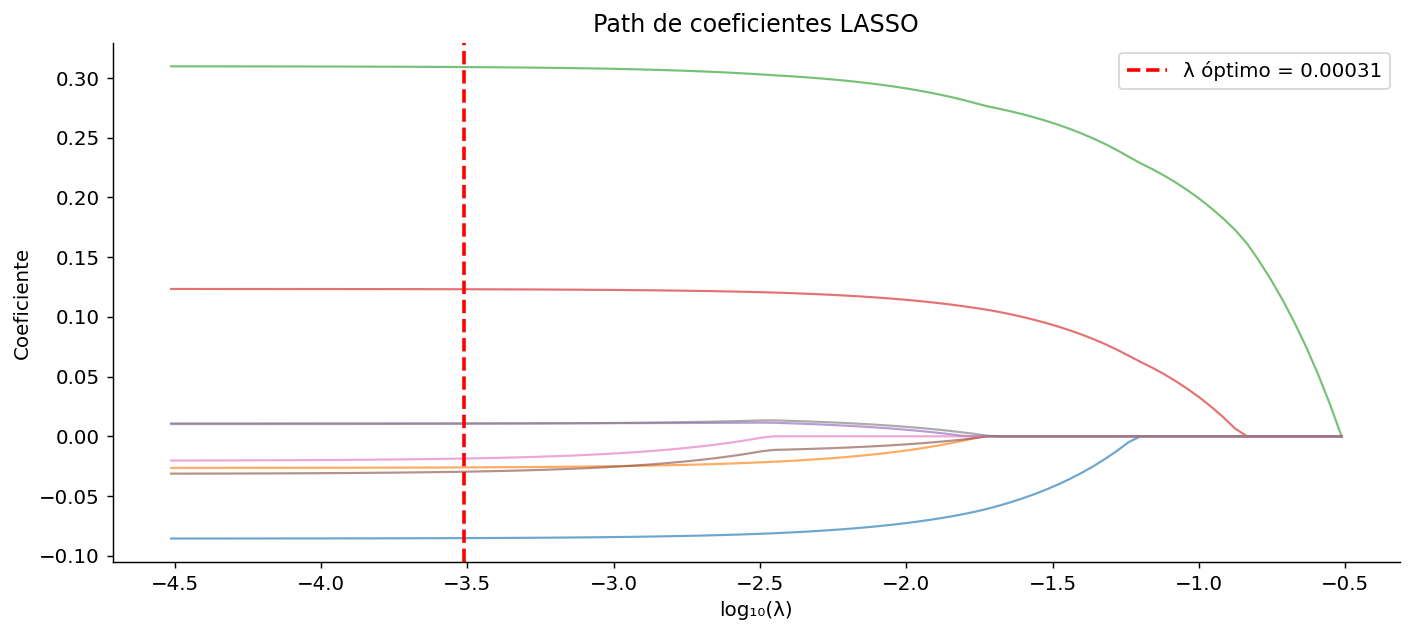

Cada línea = un predictor. Al aumentar λ los coeficientes se contraen a 0.


In [24]:
# Path de coeficientes LASSO
alphas_path, coefs_path, _ = lasso_path(X_train, y_train, eps=1e-4, n_alphas=100)

fig, ax = plt.subplots(figsize=(11, 5))
for j in range(coefs_path.shape[0]):
    ax.plot(np.log10(alphas_path), coefs_path[j, :], lw=1.2, alpha=0.65)
ax.axvline(np.log10(lambda_opt), color="red", lw=2, ls="--",
           label=f"λ óptimo = {lambda_opt:.5f}")
ax.set_xlabel("log₁₀(λ)")
ax.set_ylabel("Coeficiente")
ax.set_title("Path de coeficientes LASSO")
ax.legend()
plt.tight_layout()
plt.savefig("lasso_path.png", dpi=150, bbox_inches="tight")
plt.show()
print("Cada línea = un predictor. Al aumentar λ los coeficientes se contraen a 0.")


## 8. Comparación por AIC y BIC

$$\text{AIC} = n\log\!\left(\frac{\text{RSS}}{n}\right) + 2k
\qquad
\text{BIC} = n\log\!\left(\frac{\text{RSS}}{n}\right) + k\log n$$

Para OLS: $k = p + 1$.  
Para LASSO: $k = \text{df}(\lambda) + 1$ (coeficientes no nulos + intercepto).

> 📖 Ver Sección 4.1 del material teórico.


In [25]:
def aic_bic(y_true, y_pred, k):
    n   = len(y_true)
    rss = np.sum((np.array(y_true) - np.array(y_pred)) ** 2)
    ll  = n * np.log(rss / n)
    return {"k": k, "RSS": rss, "AIC": ll + 2*k, "BIC": ll + k*np.log(n)}

n_tr  = len(y_train)
k_ols   = X_train.shape[1] + 1      # p predictores + intercepto
k_lasso = df_lasso + 1              # df(λ) + intercepto

ic_ols   = aic_bic(y_train, y_pred_ols_train,   k=k_ols)
ic_lasso = aic_bic(y_train, y_pred_lasso_train, k=k_lasso)

tabla = pd.DataFrame({"OLS": ic_ols, "LASSO": ic_lasso}).T
print("Criterios de información (sobre train):")
print(tabla[["k", "RSS", "AIC", "BIC"]].to_string())
print(f"\nΔAIC (OLS − LASSO) = {ic_ols['AIC'] - ic_lasso['AIC']:+.2f}  (positivo → OLS peor)")
print(f"ΔBIC (OLS − LASSO) = {ic_ols['BIC'] - ic_lasso['BIC']:+.2f}  (positivo → OLS peor)")


Criterios de información (sobre train):
         k          RSS          AIC          BIC
OLS    9.0  1308.424886 -4074.848795 -4018.616743
LASSO  9.0  1308.430915 -4074.831192 -4018.599141

ΔAIC (OLS − LASSO) = -0.02  (positivo → OLS peor)
ΔBIC (OLS − LASSO) = -0.02  (positivo → OLS peor)


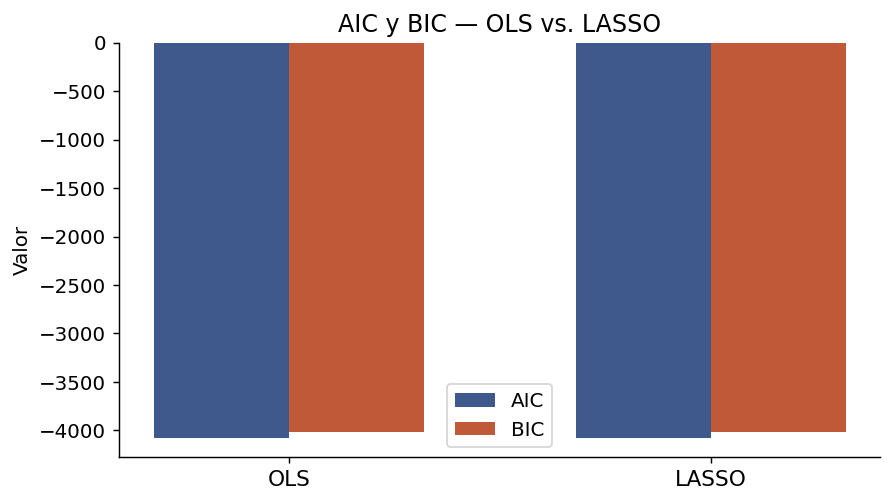

Menor AIC/BIC → modelo preferido.


In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
modelos = [OLS_LABEL, "LASSO"]
x = np.arange(2)
w = 0.32
ax.bar(x - w/2, [ic_ols["AIC"], ic_lasso["AIC"]], w, label="AIC", color=UNS_BLUE,   alpha=0.85)
ax.bar(x + w/2, [ic_ols["BIC"], ic_lasso["BIC"]], w, label="BIC", color=UNS_ORANGE, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=12)
ax.set_ylabel("Valor"); ax.set_title("AIC y BIC — OLS vs. LASSO"); ax.legend()
plt.tight_layout()
plt.savefig("aic_bic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Menor AIC/BIC → modelo preferido.")


## 9. Validación cruzada K-fold — comparación de MSE

CV externo para comparar OLS vs. LASSO en datos no vistos.
Este es el **Uso 2** de CV: comparar modelos, no calibrar λ.

> 📖 Ver Sección 4.2 del material teórico.


In [27]:
kf_ext = KFold(n_splits=K_FOLD, shuffle=True, random_state=SEED)

mse_ols_folds   = []
mse_lasso_folds = []
Xv = X_train.values
yv = y_train.values

for fold, (idx_tr, idx_val) in enumerate(kf_ext.split(Xv), 1):
    Xt, Xv_  = Xv[idx_tr], Xv[idx_val]
    yt, yv_  = yv[idx_tr], yv[idx_val]

    # OLS (con fallback Ridge si falla)
    try:
        m_ols = LinearRegression().fit(Xt, yt)
    except np.linalg.LinAlgError:
        m_ols = Ridge(alpha=1e-8).fit(Xt, yt)
    mse_ols_folds.append(mean_squared_error(yv_, m_ols.predict(Xv_)))

    # LASSO con CV interno para λ
    kf_i = KFold(n_splits=5, shuffle=True, random_state=SEED)
    m_lasso = LassoCV(cv=kf_i, max_iter=10_000, random_state=SEED).fit(Xt, yt)
    mse_lasso_folds.append(mean_squared_error(yv_, m_lasso.predict(Xv_)))

    print(f"  Fold {fold:2d} | {OLS_LABEL}: {mse_ols_folds[-1]:.4f} | LASSO: {mse_lasso_folds[-1]:.4f}")

mse_ols_cv   = np.mean(mse_ols_folds)
mse_lasso_cv = np.mean(mse_lasso_folds)
diffs_cv     = np.array(mse_ols_folds) - np.array(mse_lasso_folds)

print(f"\n{'─'*45}")
print(f"MSE CV — {OLS_LABEL}  : {mse_ols_cv:.4f}")
print(f"MSE CV — LASSO        : {mse_lasso_cv:.4f}")
print(f"Diferencia media      : {diffs_cv.mean():+.4f}")


  Fold  1 | OLS: 0.3003 | LASSO: 0.3003
  Fold  2 | OLS: 0.3706 | LASSO: 0.3702
  Fold  3 | OLS: 0.3357 | LASSO: 0.3356
  Fold  4 | OLS: 0.3191 | LASSO: 0.3192
  Fold  5 | OLS: 0.2987 | LASSO: 0.2987
  Fold  6 | OLS: 0.4394 | LASSO: 0.4395
  Fold  7 | OLS: 0.3576 | LASSO: 0.3577
  Fold  8 | OLS: 0.2758 | LASSO: 0.2761
  Fold  9 | OLS: 0.3672 | LASSO: 0.3675
  Fold 10 | OLS: 0.3745 | LASSO: 0.3744

─────────────────────────────────────────────
MSE CV — OLS  : 0.3439
MSE CV — LASSO        : 0.3439
Diferencia media      : -0.0000


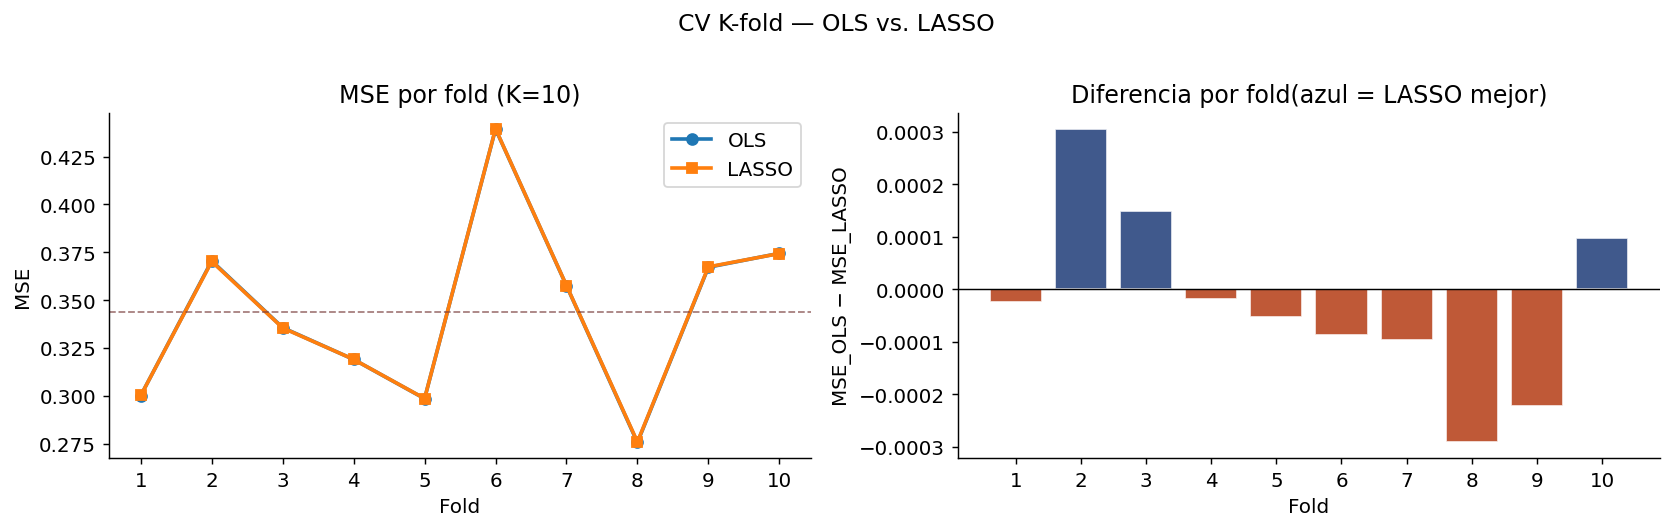

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
folds = np.arange(1, K_FOLD + 1)

axes[0].plot(folds, mse_ols_folds,   "o-", label=OLS_LABEL, lw=2)
axes[0].plot(folds, mse_lasso_folds, "s-", label="LASSO",   lw=2)
axes[0].axhline(mse_ols_cv,   ls="--", color=UNS_BLUE,   alpha=0.4, lw=1)
axes[0].axhline(mse_lasso_cv, ls="--", color=UNS_ORANGE, alpha=0.4, lw=1)
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("MSE")
axes[0].set_title(f"MSE por fold (K={K_FOLD})")
axes[0].legend(); axes[0].set_xticks(folds)

colors_bar = [UNS_BLUE if d >= 0 else UNS_ORANGE for d in diffs_cv]
axes[1].bar(folds, diffs_cv, color=colors_bar, alpha=0.85, edgecolor="white")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Fold"); axes[1].set_ylabel(f"MSE_{OLS_LABEL} − MSE_LASSO")
axes[1].set_title("Diferencia por fold(azul = LASSO mejor)")
axes[1].set_xticks(folds)

plt.suptitle("CV K-fold — OLS vs. LASSO", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("cv_kfold.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Test de Diebold-Mariano

$$DM = \frac{\bar{d}}{s_d / \sqrt{K}} \sim t(K-1) \text{ bajo } H_0$$

donde $d_k = e_{\text{OLS},k}^2 - e_{\text{LASSO},k}^2$.

> 📖 Ver Sección 4.2.4 del material teórico.


In [30]:
d_bar  = diffs_cv.mean()
s_d    = diffs_cv.std(ddof=1)
dm     = d_bar / (s_d / np.sqrt(K_FOLD))
p_dm   = 1 - t_dist.cdf(dm, df=K_FOLD - 1)

print("Test de Diebold-Mariano")
print(f"{'─'*40}")
print(f"  H₀: E[MSE_OLS] = E[MSE_LASSO]")
print(f"  H₁: E[MSE_OLS] > E[MSE_LASSO]  (LASSO predice mejor)")
print(f"{'─'*40}")
print(f"  d̄ (diferencia media)   : {d_bar:.5f}")
print(f"  s_d                    : {s_d:.5f}")
print(f"  Estadístico DM         : {dm:.3f}")
print(f"  p-valor (unilateral)   : {p_dm:.4f}")
print(f"{'─'*40}")
ALPHA = 0.05
if p_dm < ALPHA:
    print(f"  → Rechazamos H₀ al {ALPHA:.0%}: LASSO predice significativamente mejor.")
else:
    print(f"  → No rechazamos H₀ al {ALPHA:.0%}: diferencia no significativa.")


Test de Diebold-Mariano
────────────────────────────────────────
  H₀: E[MSE_OLS] = E[MSE_LASSO]
  H₁: E[MSE_OLS] > E[MSE_LASSO]  (LASSO predice mejor)
────────────────────────────────────────
  d̄ (diferencia media)   : -0.00002
  s_d                    : 0.00017
  Estadístico DM         : -0.435
  p-valor (unilateral)   : 0.6631
────────────────────────────────────────
  → No rechazamos H₀ al 5%: diferencia no significativa.


## 11. Bootstrap paramétrico

Construimos la distribución nula de $T = \text{MSE}_{\text{OLS}} - \text{MSE}_{\text{LASSO}}$
generando datos desde el modelo nulo (OLS).

> 📖 Ver Sección 4.3 del material teórico.


In [ ]:
T_obs = mse_ols_cv - mse_lasso_cv
print(f"T observado: {T_obs:.5f}")
print(f"Corriendo {B_BOOT} iteraciones bootstrap...")

# Parámetros del modelo nulo
ols_coef   = np.r_[ols.intercept_, ols.coef_]
X_aug      = np.c_[np.ones(len(Xv)), Xv]
y_hat_nulo = X_aug @ ols_coef
sigma_hat  = (yv - y_hat_nulo).std(ddof=len(ols_coef))

T_boot   = np.empty(B_BOOT)
kf_boot  = KFold(n_splits=5, shuffle=True, random_state=SEED)

for b in range(B_BOOT):
    y_star = y_hat_nulo + np.random.normal(0, sigma_hat, size=len(yv))

    mse_o_b, mse_l_b = [], []
    for idx_tr, idx_val in kf_boot.split(Xv):
        Xt_, Xv_ = Xv[idx_tr], Xv[idx_val]
        yt_, yv__ = y_star[idx_tr], y_star[idx_val]

        try:
            mo = LinearRegression().fit(Xt_, yt_)
        except np.linalg.LinAlgError:
            mo = Ridge(alpha=1e-8).fit(Xt_, yt_)
        mse_o_b.append(mean_squared_error(yv__, mo.predict(Xv_)))

        kf_i = KFold(n_splits=5, shuffle=True, random_state=SEED)
        ml   = LassoCV(cv=kf_i, max_iter=5_000, random_state=SEED).fit(Xt_, yt_)
        mse_l_b.append(mean_squared_error(yv__, ml.predict(Xv_)))

    T_boot[b] = np.mean(mse_o_b) - np.mean(mse_l_b)

    if (b + 1) % 100 == 0:
        print(f"  {b+1}/{B_BOOT} iteraciones")

p_boot = np.mean(T_boot >= T_obs)
print(f"\n✓ Bootstrap completado.  p-valor = {p_boot:.4f}")


T observado: -0.00002
Corriendo 500 iteraciones bootstrap...
  100/500 iteraciones
  200/500 iteraciones


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(T_boot, bins=50, color=UNS_BLUE, edgecolor="white", alpha=0.8,
        label="Distribución nula (bootstrap)")
ax.axvline(T_obs, color=UNS_ORANGE, lw=2.5, ls="--",
           label=f"T observado = {T_obs:.4f}")
ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax], T_obs, T_boot.max(),
                 alpha=0.15, color=UNS_ORANGE, label=f"p = {p_boot:.4f}")
ax.set_ylim(0, ymax)
ax.set_xlabel("T* = MSE_OLS − MSE_LASSO (bootstrap)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución nula — Bootstrap paramétrico")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Síntesis y decisión final

Consolidamos los resultados de las tres herramientas.

> 📖 Ver Sección 5 del material teórico.


In [ ]:
mejor_aic  = "LASSO" if ic_lasso["AIC"] < ic_ols["AIC"] else OLS_LABEL
mejor_bic  = "LASSO" if ic_lasso["BIC"] < ic_ols["BIC"] else OLS_LABEL
mejor_cv   = "LASSO" if mse_lasso_cv < mse_ols_cv else OLS_LABEL

sintesis = pd.DataFrame({
    "Herramienta"  : ["AIC", "BIC", f"CV K={K_FOLD}", "Diebold-Mariano", "Bootstrap"],
    "Resultado"    : [
        f"LASSO={ic_lasso['AIC']:.1f} vs {OLS_LABEL}={ic_ols['AIC']:.1f}",
        f"LASSO={ic_lasso['BIC']:.1f} vs {OLS_LABEL}={ic_ols['BIC']:.1f}",
        f"LASSO={mse_lasso_cv:.4f} vs {OLS_LABEL}={mse_ols_cv:.4f}",
        f"DM={dm:.3f},  p={p_dm:.4f}",
        f"p={p_boot:.4f}",
    ],
    "Favorece"     : [mejor_aic, mejor_bic, mejor_cv,
                      "LASSO" if p_dm < 0.05 else "—",
                      "LASSO" if p_boot < 0.05 else "—"],
    "Significativo": ["—", "—", "—",
                      "Sí" if p_dm   < 0.05 else "No",
                      "Sí" if p_boot < 0.05 else "No"],
})

print("SÍNTESIS — OLS vs. LASSO")
print("=" * 72)
print(sintesis.to_string(index=False))
print("=" * 72)

todos_lasso = (mejor_aic == mejor_bic == mejor_cv == "LASSO")
alguno_sig  = (p_dm < 0.05 or p_boot < 0.05)

if todos_lasso and alguno_sig:
    print("\n✓ Las tres herramientas favorecen LASSO y la diferencia es significativa.")
elif todos_lasso:
    print("\n~ Las tres herramientas favorecen LASSO pero sin significancia estadística.")
    print("  Evaluar tamaño del efecto o aumentar B_BOOT.")
else:
    print("\n⚠ Las herramientas no coinciden. Ver Sección 5.4 del material teórico.")


In [ ]:
# Figura comparativa final
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel 1: coeficientes top-15
ax1 = fig.add_subplot(gs[0])
coef_ols_arr = ols.coef_
idx_top = np.argsort(np.abs(coef_ols_arr))[-15:]
xs = np.arange(len(idx_top))
ax1.barh(xs - 0.2, coef_ols_arr[idx_top],  0.35, label=OLS_LABEL, color=UNS_BLUE,   alpha=0.85)
ax1.barh(xs + 0.2, coef_lasso[idx_top],    0.35, label="LASSO",   color=UNS_ORANGE, alpha=0.85)
ax1.set_yticks(xs)
ax1.set_yticklabels([GEN_COLS[i] for i in idx_top], fontsize=8)
ax1.axvline(0, color="black", lw=0.8)
ax1.set_title("Coeficientes\n(top 15 |OLS|)", fontsize=10)
ax1.legend(fontsize=9)

# Panel 2: predicciones en test
ax2 = fig.add_subplot(gs[1])
ax2.scatter(y_test, y_pred_ols_test,   alpha=0.25, s=10, label=OLS_LABEL, color=UNS_BLUE)
ax2.scatter(y_test, y_pred_lasso_test, alpha=0.25, s=10, label="LASSO",   color=UNS_ORANGE)
lims = [min(y_test.min(), y_pred_ols_test.min(), y_pred_lasso_test.min()),
        max(y_test.max(), y_pred_ols_test.max(), y_pred_lasso_test.max())]
ax2.plot(lims, lims, "k--", lw=1, alpha=0.5)
ax2.set_xlabel("y real"); ax2.set_ylabel("ŷ predicho")
ax2.set_title("Predicciones en test", fontsize=10)
ax2.legend(fontsize=9)

# Panel 3: bootstrap
ax3 = fig.add_subplot(gs[2])
ax3.hist(T_boot, bins=50, color=UNS_BLUE, edgecolor="white", alpha=0.8)
ax3.axvline(T_obs, color=UNS_ORANGE, lw=2, ls="--",
            label=f"T_obs={T_obs:.4f}\np={p_boot:.4f}")
ax3.set_xlabel("T* bootstrap")
ax3.set_title("Distribución nula\nbootstrap", fontsize=10)
ax3.legend(fontsize=9)

plt.suptitle("Síntesis: OLS vs. LASSO", fontsize=13)
plt.tight_layout()
plt.savefig("sintesis_final.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Resumen de secciones

| Sección | Contenido | Referencia teórica |
|---------|-----------|-------------------|
| 3 | Limpieza y transformación | Anexo A |
| 4 | Renombrado genérico + split + estandarización | Sección 1.4 |
| 5 | Correlaciones y VIF | Sección 2.1 — Supuesto S4 |
| 6 | OLS + diagnóstico residuos | Sección 2 |
| 7 | LASSO + path de coeficientes | Sección 3 |
| 8 | AIC y BIC con df efectivos | Sección 4.1 |
| 9 | CV K-fold externo | Sección 4.2 |
| 10 | Test de Diebold-Mariano | Sección 4.2.4 |
| 11 | Bootstrap paramétrico | Sección 4.3 |
| 12 | Síntesis y decisión | Sección 5 |

**Para usar con otro dataset:** reemplazar `datos_crudos.csv` y
adaptar la Sección 3 al nuevo dominio. Todo lo demás es genérico.
